In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [2]:
# Markov chains in discrete time (generations)

def get_transition_matrix(lam, rr):
    """
    State labels are 0-indexed.
    """
    PP = np.zeros((9, 9))
    PP[0] = np.array([1-2*rr-lam, 2*rr, 0, 0, 0, 0, 0, 0, lam])
    PP[1] = np.array([lam, 1-rr-3*lam, rr, lam, lam, 0, 0, 0, 0])
    PP[2] = np.array([0, 4*lam, 1-6*lam, 0, 0, lam, lam, 0, 0])
    PP[3] = np.array([0, 0, 0, 1-rr-lam, 0, rr, 0, 0, lam])
    PP[4] = np.array([0, 0, 0, 0, 1-rr-lam, 0, rr, 0, lam])
    PP[5] = np.array([0, 0, 0, lam, 0, 1-2*lam, 0, lam, 0])
    PP[6] = np.array([0, 0, 0, 0, lam, 0, 1-2*lam, lam, 0])
    PP[7] = np.array([0, 0, 0, 0, 0, 0, 0, 1-lam, lam])
    PP[8, 8] = 1
    return PP


_matrix_cache = {}


def discrete_two_locus_coal(lam, rr):
    """
    Run a monte carlo simulation of the coalescent with recombination.
    :param lam: coalescent rate 1/2N
    :param rr: recombination rate (physical)
    :returns: (TL, TR)
    """
    # cache the transition matrix.
    # we make use of the cumulative sum of the matrix on axis 1
    if (lam, rr) in _matrix_cache:
        PP = _matrix_cache[(lam, rr)]
    else:
        _PP = get_transition_matrix(lam, rr)
        PP = np.cumsum(_PP, axis=1)
        _matrix_cache[(lam, rr)] = PP
    state = 0
    TL = None 
    TR = None
    t = 0
    while state not in {7, 8}:
        p = np.random.uniform()
        state = np.searchsorted(PP[state], p)
        if TL is None:
            if state in {4, 6, 7, 8}:
                TL = t
        if TR is None:
            if state in {3, 5, 7, 8}:
                TR = t
        t += 1
    return np.array([TL, TR])


def discrete_noneq_two_locus_coal(lamfunc, rr):
    """
    Uses `lamfunc` to determine the coalescence rate at time t
    """
    state = 0
    TL = None 
    TR = None
    t = 0
    while state not in {7, 8}:
        # instantiate transition matrix or load from cache
        lam = lamfunc(t)
        if (lam, rr) in _matrix_cache:
            PPt = _matrix_cache[(lam, rr)]
        else:
            _PPt = get_transition_matrix(lam, rr)
            PPt = np.cumsum(_PPt, axis=1)
            _matrix_cache[(lam, rr)] = PPt
        p = np.random.uniform()
        state = np.searchsorted(PPt[state], p)
        if TL is None:
            if state in {4, 6, 7, 8}:
                TL = t
        if TR is None:
            if state in {3, 5, 7, 8}:
                TR = t
        t += 1
    return np.array([TL, TR])

In [3]:
# in continuous time
def get_rate_matrix(lam, rr, N_ref):
    """ 
    Also returns routing matrix
    """
    PP = get_transition_matrix(lam, rr)
    QQ = PP * 2 * N_ref
    np.fill_diagonal(QQ, 0)
    RR = np.zeros(QQ.shape)
    wait_times = np.sum(QQ, axis=1)
    RR[wait_times > 0] = QQ[wait_times > 0] / wait_times[wait_times > 0, np.newaxis]
    QQ[np.diag_indices(9, 2)] = -np.sum(QQ, axis=1)
    return QQ, RR


_rate_matrix_cache = {}


def two_locus_coal(lam, rr, N_ref):
    """
    :param lam: coalescence rate parameter
    :param rr: physical recombination parameter
    :param N_ref: reference population size
    """
    # cache the transition matrix.
    # we make use of the cumulative sum of the matrix on axis 1
    if (lam, rr, N_ref) in _matrix_cache:
        QQ, RR = _rate_matrix_cache[(lam, rr, N_ref)]
    else:
        QQ, RR = get_rate_matrix(lam, rr, N_ref)
        _rate_matrix_cache[(lam, rr, N_ref)] = (QQ, RR)
    states = np.arange(9)
    state = 0
    TL = None 
    TR = None
    t = 0
    while state not in {7, 8}:
        t += np.random.exponential(-1 / QQ[state, state])
        state = np.random.choice(states, p=RR[state])
        if TL is None:
            if state in {4, 6, 7, 8}:
                TL = t
        if TR is None:
            if state in {3, 5, 7, 8}:
                TR = t
    return np.array([TL, TR])

In [4]:
def retrieve_rate_matrix(lam, rr, N_ref):
    """ 
    Load rate/routing matrices from the cache, or initialize them if they are
    not yet cached.
    """    
    if (lam, rr, N_ref) in _matrix_cache:
        QQ, RR = _rate_matrix_cache[(lam, rr, N_ref)]
    else:
        QQ, RR = get_rate_matrix(lam, rr, N_ref)
        _rate_matrix_cache[(lam, rr, N_ref)] = (QQ, RR)
    return QQ, RR


def noneq_two_locus_coal(lam_dict, rr, N_ref=1e4):
    """
    Requires piecewise-constant population size.
    :param lam_dict: maps epoch start times to coalescence rates. eg.
        {0: 1/(2*1e3), 0.5: 1/(2*1e4)} models contraction 0.5 genetic units ago.
        genetic units are 2 * N_ref.
    :param rr: physical recombination distance parameter.
    :param N_ref: reference N for expressing time.
    """
    # extract information about the model
    # scaling of the coalescence rate acccounted for elsewhere (change this?)
    epochs = [(t / (2 * N_ref), lam) for t, lam in lam_dict.items()]
    epoch_starts = np.array([t for t, _ in epochs])
    
    states = np.arange(9)
    state = 0
    TL = None 
    TR = None
    tt = 0
    while state not in {7, 8}:
        epoch_idx = np.searchsorted(epoch_starts, tt, side="right") - 1

        # assign rate and routing matrices based on epoch
        lam = epochs[epoch_idx][1]
        QQt, RRt = retrieve_rate_matrix(lam, rr, N_ref)
        exp_scale = -1 / QQt[state, state]

        # check whether we are in the earliest epoch
        # yes;
        if epoch_idx == len(epochs) - 1:
            tt += np.random.exponential(exp_scale)
            state = np.random.choice(states, p=RRt[state])

        # no;
        else:
            # probability that the next event occurs before a change in epoch
            next_epoch_start = epochs[epoch_idx + 1][0]
            time_left = next_epoch_start - tt
            pr_event = scipy.stats.expon.cdf(time_left, scale=exp_scale)
            
            # pick whether the event occurs or not
            # yes; 
            if np.random.uniform() < pr_event:
                tt += scipy.stats.truncexpon.rvs(time_left, scale=exp_scale)
                state = np.random.choice(states, p=RRt[state])
            # no; retain the same state and pass to the next epoch
            else:
                tt += time_left

        if TL is None:
            if state in {4, 6, 7, 8}:
                TL = tt
        if TR is None:
            if state in {3, 5, 7, 8}:
                TR = tt
    return np.array([TL, TR])

In [5]:
N_ref = 1e4
lam_dict = {0: 1 / 4e4, 4e4: 1 / 2e4}
rr = 0
ts = np.array([noneq_two_locus_coal(lam_dict, rr, N_ref=N_ref) for i in range(5000)])

In [6]:
np.var(ts[:, 0]) / np.mean(ts[:, 0]) ** 2

np.float64(0.43599300433271776)

In [7]:
def _get_rate_matrix(lam, rho):
    """
    Build an intensitry matrix 
    """
    QQ = np.array(
        [[0,   rho,   0,     0,     0,     0,     0,     0,   lam],
         [lam, 0,     rho/2, lam,   lam,   0,     0,     0,   0  ],
         [0,   4*lam, 0,     0,     0,     lam,   lam,   0,   0  ],
         [0,   0,     0,     0,     0,     rho/2, 0,     0,   lam],
         [0,   0,     0,     0,     0,     0,     rho/2, 0,   lam],
         [0,   0,     0,     2*lam, 0,     0,     0,     lam, 0  ],
         [0,   0,     0,     0,     2*lam, 0,     0,     lam, 0  ],
         [0,   0,     0,     0,     0,     0,     0,     0,   lam],
         [0,   0,     0,     0,     0,     0,     0,     0,   0, ]],
         np.float64
    )
    QQ[np.diag_indices(9)] = -np.sum(QQ, axis=1)
    return QQ


def _get_routing_matrix(QQ):
    """
    Compute a routing matrix from some intensity (rate) matrix QQ. 
    :param QQ: Intensity matrix
    """
    diag = -QQ[np.diag_indices(len(QQ))]
    RR = np.zeros(QQ.shape, np.float64)
    RR[:, :] = QQ[:, :]
    np.fill_diagonal(RR, 0)
    RR[diag > 0] /= diag[diag > 0, np.newaxis]
    zeros = np.where(diag == 0)[0]
    RR[zeros, zeros] = 1
    return RR


_matrix_cache = {}


def retrieve_matrices(lam, rho):
    """ 
    Load rate/routing matrices from the cache, or initialize them if they are
    not yet cached.
    """    
    if (lam, rho) in _matrix_cache:
        QQ, RR = _matrix_cache[(lam, rho)]
    else:
        QQ = _get_rate_matrix(lam, rho)
        RR = _get_routing_matrix(QQ)
        _matrix_cache[(lam, rho)] = (QQ, RR)
    return QQ, RR


def two_locus_coal(rho, log=False):
    """
    :param rho: 
    """
    # cache the transition matrix.
    # we make use of the cumulative sum of the matrix on axis 1
    lam = 1
    QQ, RR = retrieve_matrices(lam, rho)
    states = np.arange(9)
    state = 0
    TL = None 
    TR = None
    tt = 0
    if log: 
        path = []
        times = []
    while state not in {7, 8}:
        tt += np.random.exponential(-1 / QQ[state, state])
        state = np.random.choice(states, p=RR[state])
        if TL is None:
            if state in {4, 6, 7, 8}:
                TL = tt
        if TR is None:
            if state in {3, 5, 7, 8}:
                TR = tt
        if log:
            path.append(state)
            times.append(tt)
    if log:
        record = (np.array(path, np.int64), np.array(times, np.float64))
        ret = (np.array([TL, TR]), record)
    else:
        ret = np.array([TL, TR])
    return ret


def noneq_two_locus_coal(epochs, rho, log=False):
    """
    Requires piecewise-constant population size.
    :epochs: List of tuples (t, rel. size)
    """
    # extract information about the model
    # scaling of the coalescence rate acccounted for elsewhere (change this?)
    assert epochs[-1][1] == 1
    assert epochs[0][0] == 0
    epoch_starts = np.array([t for t, _ in epochs])
    states = np.arange(9)
    state = 0
    TL = None 
    TR = None
    tt = 0
    if log:
        path = [0]
        times = [0]
    while state not in {7, 8}:
        epoch_idx = np.searchsorted(epoch_starts, tt, side="right") - 1

        # assign rate and routing matrices based on epoch
        NN = epochs[epoch_idx][1]
        lam = 1 / NN
        _rho = rho * NN
        QQt, RRt = retrieve_matrices(lam, _rho)
        exp_scale = -1 / QQt[state, state]

        # check whether we are in the earliest epoch
        # yes;
        if epoch_idx == len(epochs) - 1:
            tt += np.random.exponential(exp_scale)
            state = np.random.choice(states, p=RRt[state])

        # no;
        else:
            next_epoch_start = epochs[epoch_idx + 1][0]
            time_left = next_epoch_start - tt
            draw = np.random.exponential(exp_scale)
            if draw < time_left:
                tt += draw
                state = np.random.choice(states, p=RRt[state])
            else:
                # tt += time_left
                tt = next_epoch_start
                continue
        """
        else:
            # probability that the next event occurs before a change in epoch
            next_epoch_start = epochs[epoch_idx + 1][0]
            time_left = next_epoch_start - tt
            pr_event = scipy.stats.expon.cdf(time_left, scale=exp_scale)
            
            # pick whether the event occurs or not
            # yes; 
            if np.random.uniform() < pr_event:
                tt += scipy.stats.truncexpon.rvs(b=time_left, scale=exp_scale)
                state = np.random.choice(states, p=RRt[state])
            # no; retain the same state and pass to the next epoch
        """

        if TL is None:
            if state in {4, 6, 7, 8}:
                TL = tt
        if TR is None:
            if state in {3, 5, 7, 8}:
                TR = tt

        if log:
            path.append(state)
            times.append(tt)
    if log:
        ret = (np.array([TL, TR]),
               (np.array(path, np.float64), np.array(times, np.float64)))
    else:
        ret = np.array([TL, TR])
    return ret

In [26]:
rhos = np.logspace(-2, 2, 21)
epochs_eq = [(0, 1)]

analytic = (rhos + 18) / (rhos ** 2 + 13 * rhos + 18)
TLTR_eqs = []
empirical_eq = []
for rho in rhos:
    TLTR = np.array([noneq_two_locus_coal(epochs_eq, rho) for _ in range(5000)])
    TLTR_eqs.append(TLTR)
    empirical_eq.append(np.cov(TLTR, rowvar=False)[0, 1])

epochs = [(0, 10), (2, 1)]
TLTRs = []
empirical = []
for rho in rhos:
    TLTR = np.array([noneq_two_locus_coal(epochs, rho) for _ in range(5000)])
    TLTRs.append(TLTR)
    empirical.append(np.cov(TLTR, rowvar=False)[0, 1])

In [28]:
empirical_eq = [np.cov(x, rowvar=False)[0, 1] / np.mean(x) for x in TLTR_eqs]
empirical = [np.cov(x, rowvar=False)[0, 1] / np.mean(x) for x in TLTRs]

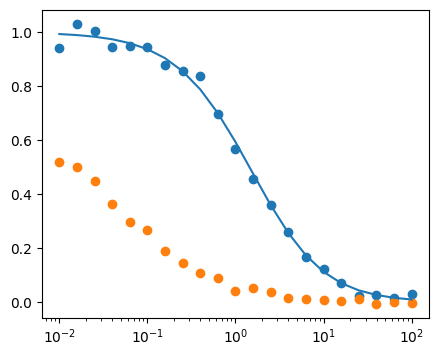

In [29]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(rhos, analytic, color="tab:blue")
plt.scatter(rhos, empirical_eq, color="tab:blue")
plt.scatter(rhos, empirical, color="tab:orange")
ax.set_xscale("log")
plt.savefig("figure.png", dpi=244)